In [1]:
import sys
sys.path.insert(0, "..")

import os
os.environ["PYTORCH_HIP_ALLOC_CONF"] = "garbage_collection_threshold:0.8"

from pathlib import Path
import random

from IPython.display import Audio, display
from tqdm import tqdm
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import mlflow

from rustic_ml.encoding import encode_adsr, decode_adsr, NOTE_MIN, NOTE_MAX, N_NOTES
from rustic_ml.dataset import random_spec, render_mel, generate_dataset, NpzDataset
from rustic_ml.analysis import MetricSpec, analyze_run
from rustic_ml.evaluation import accumulate_inference, plot_accuracy, compare_audio
from rustic_ml.mlflow_ui import show_register_widget, show_describe_widget
from rustic_py.rustic_py import render

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
if torch.cuda.is_available():
    device = "cuda"
    torch.cuda.manual_seed(SEED)
    print("CUDA detected, Using device cuda")
elif torch.backends.mps.is_available():
    device = "mps"
    print("Using MPS")
else:
    device = "cpu"
    print("No device detected, using CPU")

device = torch.device(device)

CUDA detected, Using device cuda


/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


In [4]:
print(f"Using torch {torch.__version__} device {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")
print(f"HIP version: {torch.version.hip}")
print(f"Using mlflow {mlflow.__version__}")
print(f"Rustic_ML OK - notes [{NOTE_MIN}, {NOTE_MAX}] N_NOTES={N_NOTES}")

Using torch 2.10.0+rocm7.1 device AMD Radeon Graphics
HIP version: 7.1.25424
Using mlflow 3.10.1
Rustic_ML OK - notes [36, 84] N_NOTES=49


## Hyperparameters & paths

In [5]:
# MlFlow
MLFLOW_URI = "http://localhost:5000"
MLFLOW_EXPERIMENT = "ADSRPredictor"

# Dataset
DATA_DIR = Path("/data/datasets")
N_SAMPLES = 60_000
BATCH_SIZE_GEN = 1_000

# Training parameters
BATCH_SIZE = 64
N_EPOCHS = 80
LR = 1e-3
LAMBDA_ADSR = 1e-5

## Datasets generation or loading

In [6]:
files = list(DATA_DIR.glob("*.npz"))
total = sum(np.load(p)["note"].shape[0] for p in DATA_DIR.glob("*.npz"))
print(f"Found {len(files)} dataset files ({total} total samples)")
if total < N_SAMPLES:
    missing = N_SAMPLES - total
    print(f"Missing {missing} samples, generating...")
    generate_dataset(
        missing,
        DATA_DIR,
        batch_size=BATCH_SIZE_GEN,
        waveform="sine",
        start_batch=len(files),
        n_workers=12
    )

Found 150 dataset files (150000 total samples)


In [7]:
all_files = random.sample(sorted(DATA_DIR.glob("*.npz")), round(N_SAMPLES / BATCH_SIZE_GEN))
print(f"Selecting {round(N_SAMPLES / BATCH_SIZE_GEN)} files for ~{N_SAMPLES} samples")
split = int(0.8 * len(all_files))

train_ds = NpzDataset(all_files[:split])
val_ds   = NpzDataset(all_files[split:])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)} samples  Val: {len(val_ds)} samples")

Selecting 60 files for ~60000 samples
Train: 48000 samples  Val: 12000 samples


## Model

In [8]:
class ADSRPredictor(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, None))
        self.note_head = nn.Linear(128 * 5, N_NOTES)
        self.adsr_head = nn.Linear(128 * 5, 4)
        self.dropout = nn.Dropout(0.3)

    def forward(self, mel) -> tuple:
        x = self.conv1(mel)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.pool(x)
        x = x.flatten(start_dim=1)
        x = self.dropout(x)

        adsr_raw = self.adsr_head(x)
        adsr_out = adsr_raw.clone()
        adsr_out[:, 2] = torch.sigmoid(adsr_raw[:, 2])
        return self.note_head(x), adsr_out

In [9]:
model = ADSRPredictor().to(device)

criterion_note = nn.CrossEntropyLoss()
criterion_adsr = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print("Model moved to device")
print(torch.cuda.memory_allocated() / 1e6, "MB allocated")
print(torch.cuda.memory_reserved() / 1e6, "MB reserved")

Model moved to device
0.537088 MB allocated
2.097152 MB reserved


## Training

In [10]:
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

<Experiment: artifact_location='/data/artifacts/1', creation_time=1773911017921, experiment_id='1', last_update_time=1773911017921, lifecycle_stage='active', name='ADSRPredictor', tags={}, workspace='default'>

In [11]:
def compute_and_log_metrics(train_losses: dict, train_n_batches: int, val_losses: dict, val_n_batches: int, val_accuracy: float):
    mlflow.log_metrics({
        "train/loss":      train_losses["loss"] / train_n_batches,
        "train/loss_note": train_losses["note"] / train_n_batches,
        "train/loss_adsr": train_losses["adsr"] / train_n_batches,
        "val/loss":        val_losses["loss"] / val_n_batches,
        "val/loss_note":   val_losses["note"] / val_n_batches,
        "val/loss_adsr":   val_losses["adsr"] / val_n_batches,
        "val/accuracy_note": val_accuracy,
    }, step=epoch)

Epoch: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [25:42<00:00, 19.28s/it]


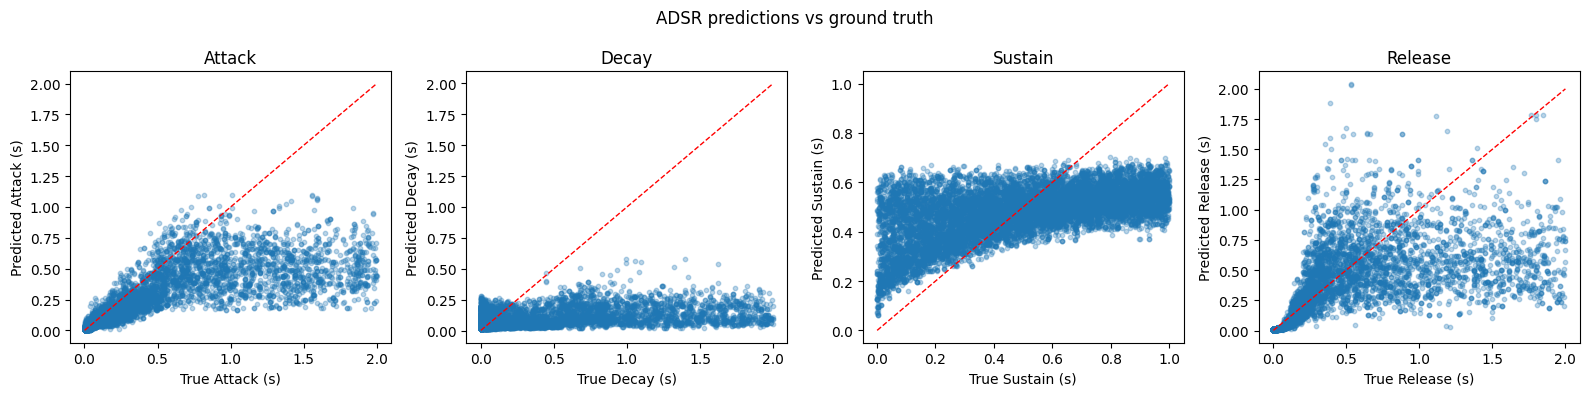

Note accuracy: 1.000


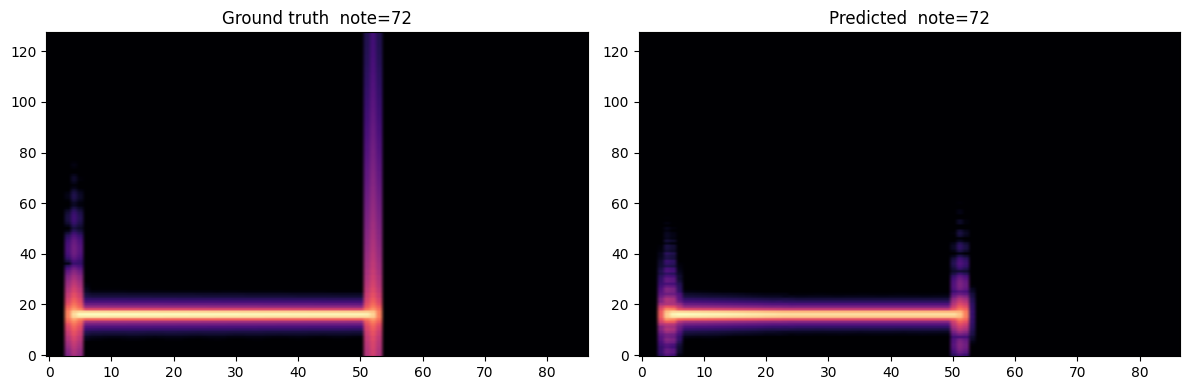

Ground truth — note=72  A=0.002 D=1.066 S=0.626 R=0.003


Predicted    — note=72  A=0.008 D=0.208 S=0.521 R=0.004


2026/03/20 11:51:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/20 11:51:38 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/20 11:51:38 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+rocm7.1) contains a local version label (+rocm7.1). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/20 11:51:41 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+rocm7.1) contains a local version label (+r

🏃 View run judicious-snake-779 at: http://localhost:5000/#/experiments/1/runs/c932cb6033c4438d9fb08832e2b0974e
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [12]:
with mlflow.start_run() as run:
    RUN_ID = run.info.run_id
    
    mlflow.log_params({
        "samples": N_SAMPLES,
        "batch_size": BATCH_SIZE,
        "epochs": N_EPOCHS,
        "lr": LR,
        "lambda ADSR": LAMBDA_ADSR,
    })

    for epoch in tqdm(range(N_EPOCHS), desc=f"Epoch"):
        # Train
        model.train()
        train_losses = {"loss": 0.0, "note": 0.0, "adsr": 0.0}
        for mel, note, adsr in train_loader:
            mel, note, adsr = mel.to(device), note.to(device), adsr.to(device)

            optimizer.zero_grad()
            note_logits, adsr_pred = model(mel)

            loss_note = criterion_note(note_logits, note - NOTE_MIN)
            loss_adsr = criterion_adsr(adsr_pred, adsr)
            loss = loss_note + LAMBDA_ADSR * loss_adsr

            train_losses["loss"] += loss.item()
            train_losses["note"] += loss_note.item()
            train_losses["adsr"] += loss_adsr.item()

            loss.backward()
            optimizer.step()

        # Eval
        model.eval()
        val_losses = {"loss": 0.0, "note": 0.0, "adsr": 0.0}
        val_accuracy_dict = {"correct": 0, "total": 0}
        with torch.no_grad():
            for mel, note, adsr in val_loader:
                mel, note, adsr = mel.to(device), note.to(device), adsr.to(device)

                note_logits, adsr_pred = model(mel)
                
                val_accuracy_dict["correct"] += (note_logits.argmax(dim=1) == note - NOTE_MIN).sum().item()
                val_accuracy_dict["total"]   += note.size(0)

                loss_note = criterion_note(note_logits, note - NOTE_MIN)
                loss_adsr = criterion_adsr(adsr_pred, adsr)
                loss = loss_note + LAMBDA_ADSR * loss_adsr

                val_losses["loss"] += loss.item()
                val_losses["note"] += loss_note.item()
                val_losses["adsr"] += loss_adsr.item()

        compute_and_log_metrics(
            train_losses, len(train_loader),
            val_losses, len(val_loader),
            val_accuracy_dict["correct"] / val_accuracy_dict["total"]
        )

    # Accumulation loop for model evaluation
    vals = accumulate_inference(model, val_loader, device)

    # Plot accuracy
    plot_accuracy(vals)

    # Audio comparison
    compare_audio(model, val_ds, device)

    # Log the model
    mlflow.pytorch.log_model(model, "model")

## Post-training analysis

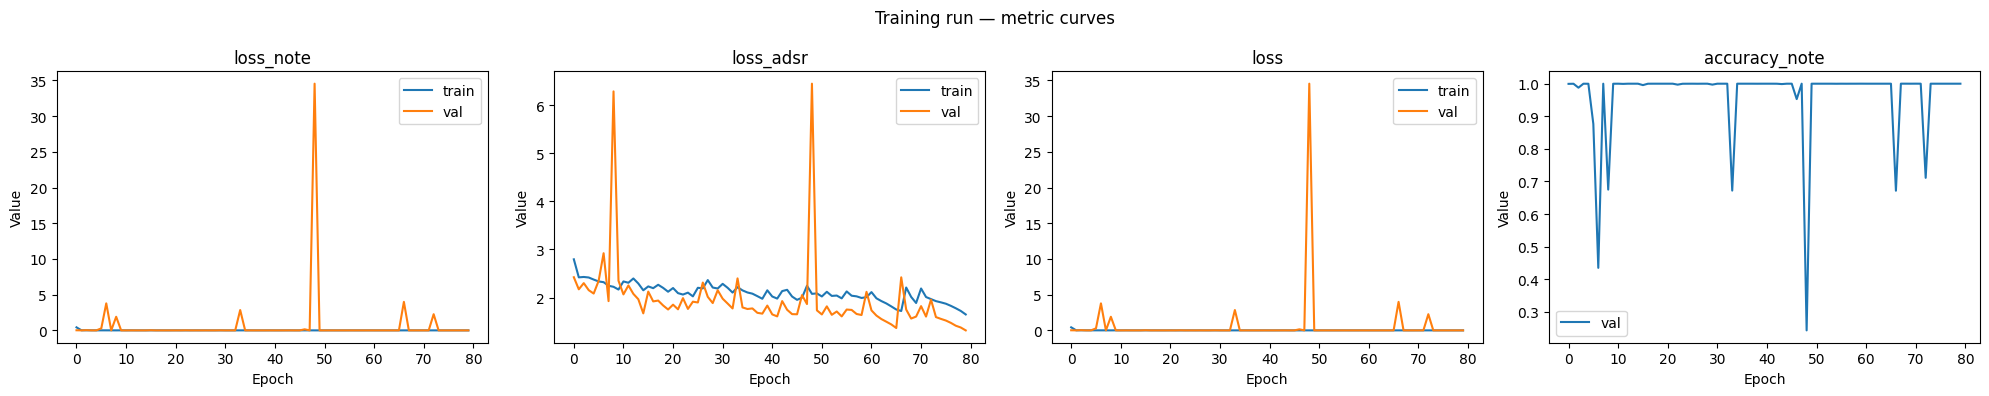

[OVERFITTING] train/loss_note=0.0000 vs val/loss_note=0.0002 (gap=0.0002) — try: more data, dropout, or weight decay (try n_samples=120000)
[OVERFITTING] train/loss=0.0000 vs val/loss=0.0002 (gap=0.0002) — try: more data, dropout, or weight decay (try n_samples=120000)
[STILL LEARNING] train/loss_adsr slope over last 20% of epochs = -0.01094 — training should continue (try n_epochs=230)
[LOSS IMBALANCE] train/loss_note=0.0000 << train/loss_adsr=1.6489 (ratio=0.0000) — ADSR loss dominates gradient updates; try decreasing LAMBDA_ADSR to rebalance (try lambda_adsr=0.0)


In [13]:
METRICS = [
    MetricSpec("train/loss_note",   "train", "loss_note"),
    MetricSpec("val/loss_note",     "val",   "loss_note"),
    MetricSpec("train/loss_adsr",   "train", "loss_adsr"),
    MetricSpec("val/loss_adsr",     "val",   "loss_adsr"),
    MetricSpec("train/loss",        "train", "loss"),
    MetricSpec("val/loss",          "val",   "loss"),
    MetricSpec("val/accuracy_note", "val",   "accuracy_note"),
]

analyze_run(METRICS, run_id=RUN_ID, tracking_uri=MLFLOW_URI)

In [14]:
show_register_widget(RUN_ID, tracking_uri=MLFLOW_URI)
show_describe_widget(RUN_ID, tracking_uri=MLFLOW_URI)

Output()

Output()

In [ ]:
def compare_to_previous_model(model_name: str):
    """
    TODO: Fetch previous model (if any) and compare with the current model.
    If the current model is clearly better, register it as the new version
    """
    ...